# 08 — Multivariate Regression: Altitude + Temperature

For each crop with a significant altitude signal, fits three models:
1. altitude alone
2. temperature alone  
3. altitude + temperature jointly (OLS)

Key question: **Does altitude remain significant after controlling for temperature?**
This directly addresses the reviewer concern that altitude is proxying temperature.

Saves `../writing/fig_multivariate.png`

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import linregress
from scipy import stats

from rsu_loader import load_all_rsus

WRITING = '../writing'

rsus = load_all_rsus()

# Build RSU-level env DataFrame (altitude, temperature) — not in matrix CSV
env_rows = []
for r in rsus:
    env_rows.append({
        'region_id': r.region_id,
        'altitude_m': getattr(r.coordinates, 'altitude_m', None),
        'temp_mean':  r.climate.temperature_mean,
    })
env_df = pd.DataFrame(env_rows).set_index('region_id')

# Load metabolite matrix and merge env columns
import os
matrix_path = '../data/metabolites/rsu_metabolite_matrix.csv'
if os.path.exists(matrix_path):
    food_df_raw = pd.read_csv(matrix_path, index_col=[0, 1])
    food_df = food_df_raw.join(env_df, on='region_id')
    print(f'Loaded matrix: {food_df.shape}')
else:
    print('Matrix not found — run notebook 01 first')
    raise FileNotFoundError(matrix_path)

Loaded matrix: (268, 35)


In [2]:
from scipy.stats import t as t_dist

def ols_bivariate(x, y):
    """Return (r2, p, slope, intercept) for simple OLS."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    mask = ~(np.isnan(x) | np.isnan(y))
    if mask.sum() < 3:
        return None, None, None, None
    sl, inter, r, p, _ = linregress(x[mask], y[mask])
    return r**2, p, sl, inter

def ols_multivariate(x1, x2, y):
    """OLS with two predictors. Returns (r2_adj, p_x1, p_x2, coef_x1, coef_x2)."""
    x1, x2, y = np.asarray(x1, float), np.asarray(x2, float), np.asarray(y, float)
    mask = ~(np.isnan(x1) | np.isnan(x2) | np.isnan(y))
    n = mask.sum()
    if n < 4:
        return None, None, None, None, None
    X = np.column_stack([np.ones(n), x1[mask], x2[mask]])
    Y = y[mask]
    # Normal equations
    try:
        b = np.linalg.lstsq(X, Y, rcond=None)[0]
    except:
        return None, None, None, None, None
    y_hat = X @ b
    ss_res = np.sum((Y - y_hat)**2)
    ss_tot = np.sum((Y - Y.mean())**2)
    r2 = 1 - ss_res / ss_tot
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - 3)
    # Individual p-values via t-test
    mse = ss_res / (n - 3)
    var_b = mse * np.linalg.inv(X.T @ X).diagonal()
    se_b = np.sqrt(var_b)
    t_stats = b / se_b
    p_vals = [2 * t_dist.sf(abs(t), df=n-3) for t in t_stats]
    return r2_adj, p_vals[1], p_vals[2], b[1], b[2]

def sig_stars(p):
    if p is None: return ''
    if p < 0.001: return '★★★'
    if p < 0.01:  return '★★'
    if p < 0.05:  return '★'
    if p < 0.10:  return '†'
    return 'ns'

print('Helpers ready')

Helpers ready


In [3]:
# ── Extract per-crop datasets ─────────────────────────────────────────────────
CGA_COL   = 'key_flavor_bioactives.polyphenol_content'
MALIC_COFFEE = 'organic_acids.malic_acid'
CLA_COL   = 'key_flavor_bioactives.conjugated_linoleic_acid'
MALIC_APPLE  = 'organic_acids.malic_acid'
CAT_COL   = 'key_flavor_bioactives.polyphenol_content'  # tea catechins

# Coffee
coffee_ids = {'RSU-47', 'RSU-48', 'RSU-18', 'RSU-27', 'RSU-54', 'RSU-17'}
coffee_mask = food_df.index.get_level_values('food_name').str.lower().str.contains('coffee|arabica')
coffee_df = food_df[coffee_mask]
coffee_df = coffee_df[coffee_df.index.get_level_values('region_id').isin(coffee_ids)]

# Butter (grass-fed) — one row per RSU.
# RSU-42 matches twice ("yak butter" and "butter tea po cha"); keep only the pure butter.
butter_ids = {'RSU-46', 'RSU-37', 'RSU-51', 'RSU-52', 'RSU-53', 'RSU-36', 'RSU-42'}
butter_mask = (food_df.index.get_level_values('food_name').str.lower().str.contains('butter') &
               ~food_df.index.get_level_values('food_name').str.lower().str.contains('tea|po cha'))
butter_df = food_df[butter_mask]
butter_df = butter_df[butter_df.index.get_level_values('region_id').isin(butter_ids)]

# Apple
apple_ids = {'RSU-13', 'RSU-49', 'RSU-55', 'RSU-14', 'RSU-50'}
apple_mask = food_df.index.get_level_values('food_name').str.lower().str.contains('golden delicious')
apple_df = food_df[apple_mask]
apple_df = apple_df[apple_df.index.get_level_values('region_id').isin(apple_ids)]

# Tea — one row per RSU: first food with polyphenol in 5–30 g/100g range
TEA_INCLUDE = {'RSU-20', 'RSU-27', 'RSU-56', 'RSU-58', 'RSU-61', 'RSU-62', 'RSU-63', 'RSU-64', 'RSU-65'}
TEA_EXCLUDE = {'RSU-22', 'RSU-26', 'RSU-57', 'RSU-60'}
tea_rows = []
for rid in TEA_INCLUDE - TEA_EXCLUDE:
    sub = food_df[food_df.index.get_level_values('region_id') == rid]
    if CAT_COL not in sub.columns:
        continue
    for _, row in sub.iterrows():
        val = pd.to_numeric(row[CAT_COL], errors='coerce')
        if pd.notna(val) and 5 < val < 30:
            tea_rows.append(row.rename(rid))
            break
tea_df = pd.DataFrame(tea_rows)
tea_df.index.name = 'region_id'

print(f'Coffee: {len(coffee_df)} RSUs')
print(f'Butter: {len(butter_df)} RSUs')
print(f'Apple:  {len(apple_df)} RSUs')
print(f'Tea:    {len(tea_df)} RSUs')
print('Tea RSUs:', list(tea_df.index))

Coffee: 6 RSUs
Butter: 7 RSUs
Apple:  5 RSUs
Tea:    9 RSUs
Tea RSUs: ['RSU-61', 'RSU-64', 'RSU-27', 'RSU-58', 'RSU-56', 'RSU-62', 'RSU-65', 'RSU-20', 'RSU-63']


In [4]:
# ── Run all three models for each crop ───────────────────────────────────────
# crops: (label, df, xcol, tcol, ycol, log_x)
# log_x=True uses log(altitude) — pre-specified for butter CLA
results = []

crops = [
    ('Coffee CGA',    coffee_df, 'altitude_m', 'temp_mean', CGA_COL,      False),
    ('Coffee malic',  coffee_df, 'altitude_m', 'temp_mean', MALIC_COFFEE,  False),
    ('Butter CLA',    butter_df, 'altitude_m', 'temp_mean', CLA_COL,       True),
    ('Apple malic',   apple_df,  'altitude_m', 'temp_mean', MALIC_APPLE,   False),
]
if len(tea_df) >= 4 and CAT_COL in tea_df.columns:
    crops.append(('Tea catechins', tea_df, 'altitude_m', 'temp_mean', CAT_COL, False))

for label, df, xcol, tcol, ycol, log_x in crops:
    if ycol not in df.columns:
        print(f'[skip] {label}: column {ycol} not in df')
        continue
    x_raw = pd.to_numeric(df[xcol], errors='coerce')
    x = np.log(x_raw.clip(lower=1e-9)) if log_x else x_raw
    temp = pd.to_numeric(df[tcol], errors='coerce')
    y = pd.to_numeric(df[ycol], errors='coerce')
    n = (~(x.isna() | y.isna())).sum()

    r2_alt,  p_alt,  sl_alt,  _ = ols_bivariate(x, y)
    r2_tmp,  p_tmp,  sl_tmp,  _ = ols_bivariate(temp, y)
    r2_adj, p_alt_mv, p_tmp_mv, b_alt, b_tmp = ols_multivariate(x, temp, y)

    results.append({
        'Crop': label, 'n': n, 'log_x': log_x,
        'r2_alt': r2_alt,   'p_alt': p_alt,
        'r2_tmp': r2_tmp,   'p_tmp': p_tmp,
        'r2_adj_mv': r2_adj, 'p_alt_mv': p_alt_mv, 'p_tmp_mv': p_tmp_mv,
        'b_alt': b_alt, 'b_tmp': b_tmp,
    })

resdf = pd.DataFrame(results)
print(resdf[['Crop', 'n', 'log_x', 'r2_alt', 'p_alt', 'r2_tmp', 'p_tmp', 'r2_adj_mv', 'p_alt_mv', 'p_tmp_mv']].to_string(index=False))

         Crop  n  log_x   r2_alt    p_alt   r2_tmp    p_tmp  r2_adj_mv  p_alt_mv  p_tmp_mv
   Coffee CGA  6  False 0.874137 0.006209 0.886623 0.005015   0.947272  0.068756  0.058168
 Coffee malic  5  False 0.921204 0.009619 0.964653 0.002851   0.969310  0.247757  0.102640
   Butter CLA  7   True 0.922969 0.000575 0.706193 0.017913   0.886090  0.027591  0.822344
  Apple malic  5  False 0.912011 0.011384 0.579669 0.134821   0.827336  0.108591  0.862779
Tea catechins  9  False 0.490253 0.035701 0.395341 0.069702   0.690908  0.020944  0.036436


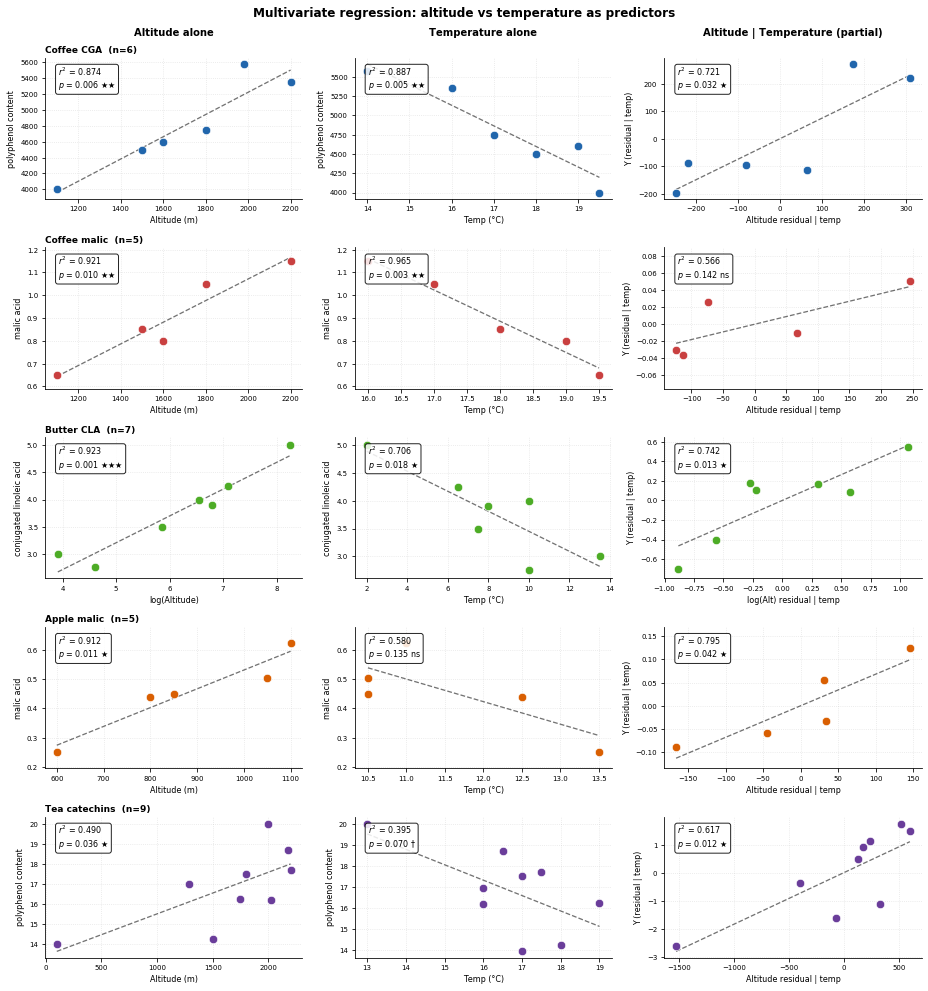

Saved → ../writing/fig_multivariate.png


In [5]:
# ── Figure: 3-column comparison for each crop ────────────────────────────────
RCPARAMS = {'font.family': 'sans-serif', 'axes.spines.top': False,
            'axes.spines.right': False, 'axes.grid': True,
            'grid.alpha': 0.35, 'grid.linestyle': ':'}

def ann_mv(ax, r2, p, label, x0=0.05, y0=0.95):
    stars = sig_stars(p)
    txt = f'$r^2$ = {r2:.3f}\n$p$ = {p:.3f} {stars}'
    ax.text(x0, y0, txt, transform=ax.transAxes,
            ha='left', va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))

colors = ['#2166ac', '#c94040', '#4dac26', '#d95f02', '#6a3d9a']

with plt.rc_context(RCPARAMS):
    n_crops = len(results)
    fig, axes = plt.subplots(n_crops, 3, figsize=(13, 2.8 * n_crops))
    if n_crops == 1:
        axes = axes[np.newaxis, :]

    # Column headers: tight pad so row labels (placed above at y=1.18) clear them
    col_titles = ['Altitude alone', 'Temperature alone', 'Altitude | Temperature (partial)']
    for ax, ct in zip(axes[0], col_titles):
        ax.set_title(ct, fontsize=10, fontweight='bold', pad=22)

    for row_idx, (res, (label, df, xcol, tcol, ycol, log_x)) in enumerate(zip(results, crops)):
        if ycol not in df.columns:
            continue
        x_raw = pd.to_numeric(df[xcol], errors='coerce').values
        x = np.log(np.clip(x_raw, 1e-9, None)) if log_x else x_raw
        temp = pd.to_numeric(df[tcol], errors='coerce').values
        y = pd.to_numeric(df[ycol], errors='coerce').values
        color = colors[row_idx % len(colors)]
        alt_xlabel = 'log(Altitude)' if log_x else 'Altitude (m)'

        # Row label via ax.text at y=1.18 — sits one full line above the column header,
        # completely independent of set_title() so no collision on row 0
        axes[row_idx, 0].text(0, 1.02, f'{label}  (n={res["n"]})',
                              transform=axes[row_idx, 0].transAxes,
                              fontsize=9, fontweight='bold', va='bottom', ha='left',
                              clip_on=False)

        for col, (xdata, xlabel, r2, p) in enumerate([
            (x,    alt_xlabel,  res['r2_alt'], res['p_alt']),
            (temp, 'Temp (°C)', res['r2_tmp'], res['p_tmp']),
        ]):
            ax = axes[row_idx, col]
            mask = ~(np.isnan(xdata) | np.isnan(y))
            ax.scatter(xdata[mask], y[mask], color=color, s=70,
                       edgecolors='white', linewidths=0.6, zorder=3)
            if mask.sum() >= 2:
                xl = np.linspace(xdata[mask].min(), xdata[mask].max(), 200)
                sl, inter, *_ = linregress(xdata[mask], y[mask])
                ax.plot(xl, sl*xl + inter, '--', color='black', lw=1.3, alpha=0.55)
            if r2 is not None:
                ann_mv(ax, r2, p, label)
            ax.set_xlabel(xlabel, fontsize=8)
            ax.set_ylabel(ycol.split('.')[-1].replace('_', ' '), fontsize=8)
            ax.tick_params(labelsize=7)

        # Column 3: residual plot — altitude after partialling out temperature
        ax = axes[row_idx, 2]
        mask = ~(np.isnan(x) | np.isnan(temp) | np.isnan(y))
        if mask.sum() >= 4:
            sl_t, inter_t, *_ = linregress(temp[mask], x[mask])
            x_resid = x[mask] - (sl_t * temp[mask] + inter_t)
            sl_ty, inter_ty, *_ = linregress(temp[mask], y[mask])
            y_resid = y[mask] - (sl_ty * temp[mask] + inter_ty)
            ax.scatter(x_resid, y_resid, color=color, s=70,
                       edgecolors='white', linewidths=0.6, zorder=3)
            sl_r, inter_r, r_r, p_r, _ = linregress(x_resid, y_resid)
            xl = np.linspace(x_resid.min(), x_resid.max(), 200)
            ax.plot(xl, sl_r*xl + inter_r, '--', color='black', lw=1.3, alpha=0.55)
            ann_mv(ax, r_r**2, p_r, 'partial')
            resid_xlabel = 'log(Alt) residual | temp' if log_x else 'Altitude residual | temp'
            ax.set_xlabel(resid_xlabel, fontsize=8)
            ax.set_ylabel('Y (residual | temp)', fontsize=8)
            ax.tick_params(labelsize=7)

    fig.suptitle('Multivariate regression: altitude vs temperature as predictors',
                 fontsize=12, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    path = f'{WRITING}/fig_multivariate.png'
    fig.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved → {path}')

In [6]:
# ── Summary table for paper ───────────────────────────────────────────────────
print('\n=== MULTIVARIATE MODEL SUMMARY ===')
print(f'{"Crop":<20} {"n":>3}  {"Altitude-only r²":>16}  {"Temp-only r²":>12}  {"Joint adj-r²":>12}  {"p(alt|temp)":>12}  {"p(temp|alt)":>12}')
for res in results:
    r2a  = f"{res['r2_alt']:.3f} {sig_stars(res['p_alt'])}"
    r2t  = f"{res['r2_tmp']:.3f} {sig_stars(res['p_tmp'])}"
    r2mv = f"{res['r2_adj_mv']:.3f}" if res['r2_adj_mv'] else 'n/a'
    pa   = f"{res['p_alt_mv']:.3f} {sig_stars(res['p_alt_mv'])}" if res['p_alt_mv'] else 'n/a'
    pt   = f"{res['p_tmp_mv']:.3f} {sig_stars(res['p_tmp_mv'])}" if res['p_tmp_mv'] else 'n/a'
    print(f"{res['Crop']:<20} {res['n']:>3}  {r2a:>16}  {r2t:>12}  {r2mv:>12}  {pa:>12}  {pt:>12}")


=== MULTIVARIATE MODEL SUMMARY ===
Crop                   n  Altitude-only r²  Temp-only r²  Joint adj-r²   p(alt|temp)   p(temp|alt)
Coffee CGA             6          0.874 ★★      0.887 ★★         0.947       0.069 †       0.058 †
Coffee malic           5          0.921 ★★      0.965 ★★         0.969      0.248 ns      0.103 ns
Butter CLA             7         0.923 ★★★       0.706 ★         0.886       0.028 ★      0.822 ns
Apple malic            5           0.912 ★      0.580 ns         0.827      0.109 ns      0.863 ns
Tea catechins          9           0.490 ★       0.395 †         0.691       0.021 ★       0.036 ★
